In [1]:
#-----#
#Used for nested sweeping of Keithley SMUs, for recording I,V from Keithleys and Nanovoltmeters
#Using QCodes for data storage, 
#Use plottr-inspectr for real-time plotting (open separately)

#Created by Lewis P. and Eli H
#Updated 16/10/2025


###NANOVOLTMETERS NOT SUPPORTED



In [2]:
#just imports helper functions software
from import_all import *
from utilities import *
import trigger_fns
from pathlib import Path


In [3]:
#----Connect to instrument----#
#load the station from yaml configuration file
station = Station(config_file="electrochemistry.station.yaml")
keithley1 = station.load_keithley1()
keithley2 = station.load_keithley2()

keithleys = [keithley1]


Connected to: Keithley Instruments Inc. 2636B (serial:4629010, firmware:3.4.0) in 0.70s
Connected to: Keithley Instruments Inc. 2614B (serial:4070377, firmware:3.0.4) in 0.11s


----top_gate----
Will scan top_gate from -0.8 to 0.8 in 10.0 mV steps
Starting and ending at 0
Scan speed for top_gate: 10.0 mV/s
Number of points for top_gate: 161 steps
----drain_source----
Keeping drain_source fixed at 0.01 V
ramping top_gate to 0.0
ramping <Keithley2600Channel: keithley1_smub of Keithley2600: keithley1> from -0.649993 to 0.0
ramping drain_source to 0.01
ramping <Keithley2600Channel: keithley1_smua of Keithley2600: keithley1> from 0.0102282 to 0.01
Delay for 1 s...
Starting sweeps
Starting experimental run with id: 10. 
Repeat: 0
----top_gate----
Will scan top_gate from -0.9 to 0.9 in 10.0 mV steps
Starting and ending at 0
Scan speed for top_gate: 10.0 mV/s
Number of points for top_gate: 181 steps
----drain_source----
Keeping drain_source fixed at 0.01 V
ramping top_gate to 0.0
ramping <Keithley2600Channel: keithley1_smub of Keithley2600: keithley1> from -0.000257492 to 0.0
ramping drain_source to 0.01
ramping <Keithley2600Channel: keithley1_smua of Keithley2600: ke

An exception occurred in measurement with guid: 33d5fd19-0000-0000-0000-019c4359fb1a;
Traceback:
Traceback (most recent call last):
  File "C:\Users\Eli Hoenig\AppData\Local\Temp\ipykernel_21292\1336497567.py", line 239, in <module>
    v, j = trigger_fns.recall_buffer(sweeper["channel"])
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Eli Hoenig\Documents\Python Scripts\pyKeithleyControl_trigger\scripts\trigger_fns.py", line 42, in recall_buffer
    j = ch.ask(f"{ch.channel}.nvbuffer1.readings[1]")
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Eli Hoenig\anaconda3\envs\k_control\Lib\site-packages\qcodes\instrument\channel.py", line 66, in ask
    return self._parent.ask(cmd)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Eli Hoenig\Documents\Python Scripts\pyKeithleyControl_trigger\scripts\Keithley_2600.py", line 1013, in ask
    return super().ask(f"print({cmd:s})")
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Eli Hoe

Received SIGINT, Will interrupt at first suitable time. Send second SIGINT to interrupt immediately.


KeyboardInterrupt: 

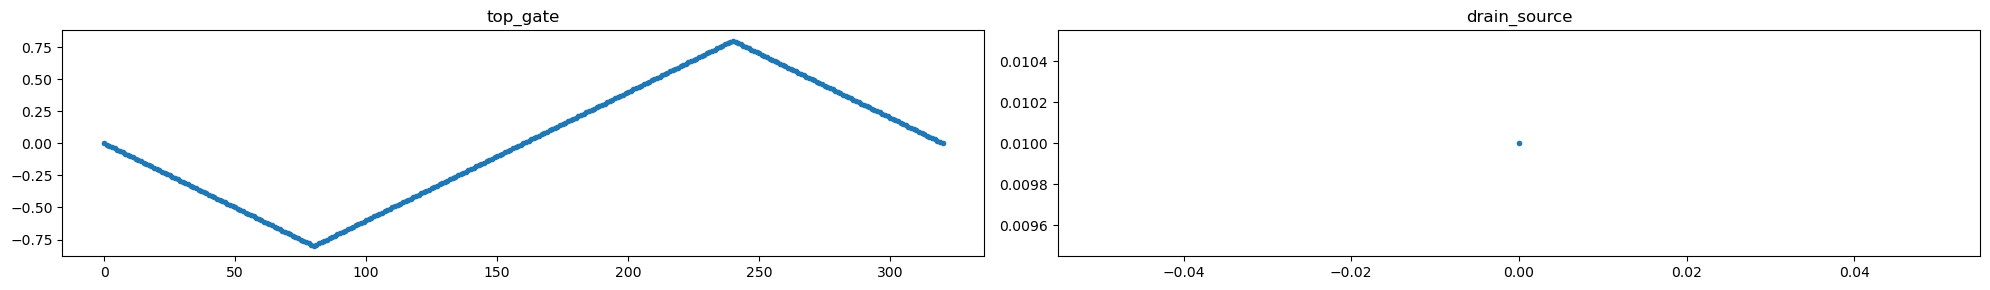

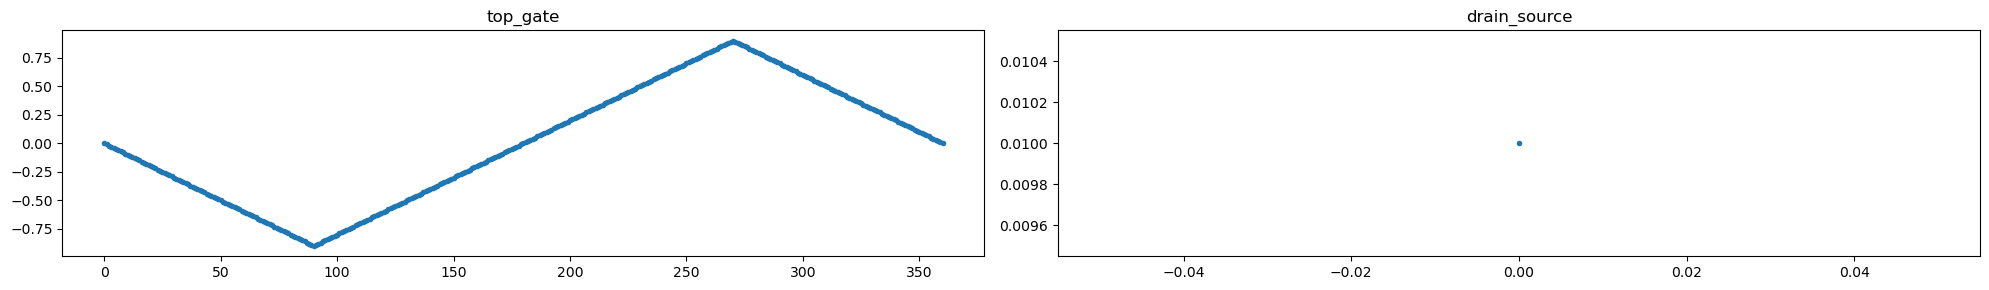

In [10]:
####################################
#----Configure channels----#
####################################
keithleys = [keithley1]
d = 0
while d <= 1:
    ch1 = { "channel": keithley1.smub,
            "name": "top_gate", 
            "first_node": np.max([-0.8 - d, -1]), # from start -> first_node -> second_node -> start
            "second_node": 0.8 + d,
            "start_voltage": 0,
            "dV": 0.01, #voltage step
            "independent": True,  #independent variable for plotting purposes? Can be buggy if more than one independent variable
            "manual": False,
            "manual_vRange": [],
                
    }


    # ch2 = { "channel": keithley1.smub,
    #         "name": "bot_gate",
    #         "first_node": -0.3, # from start -> first_node -> second_node -> start
    #         "second_node": 0.7,
    #         "start_voltage": 0,
    #         "dV": 0.01, #voltage step
    #         "independent": not False,  #independent variable for plotting purposes? Can be buggy if more than one independent variable
    #         "manual": False,
    #         "manual_vRange": []
    # }

    ch3 = { "channel": keithley1.smua,
            "name": "drain_source",
            "first_node":0.01,
            "second_node": 0.01,
            "start_voltage":0.01,
            "dV": 0.0,
            "independent":  False,
            "manual": False,
            "manual_vRange": []

    }

    # ch4 = { "channel": keithley2.smua,
    #         "name": "temperature", #handled differently. If measuring temperature, make sure to include "temperature" in name
    #         "first_node":5e-3,
    #         "second_node": 5e-3,
    #         "start_voltage":5e-3,
    #         "dV": 0,
    #         "independent":  False,
    #         "manual": False,
    #         "manual_vRange": []

    # }

    #---Save paths----#
    csv_save_path = "../csv/260209/"
    db_save_path = "../db/260209/"
    device_name = "WOx on 90nm SiO2 S2" #master database file
    xpmnt_name = f"tg={ch1['first_node']} to {ch1['second_node']} RT"#xpmnt name within database. Saved as seperate csv
    csv_path = Path(csv_save_path)
    db_path = Path(db_save_path)

    ####################################
    #----Configure sweeping params----#
    ####################################
    time_independent = False  #plot time as indepent variable?

    ramp_up = True # ramp to initial values?
    ramp_down = True #ramp back to 0?

    temp_measure = True

    ktime_control = True

    dt_list = [1]
    dt = dt_list[0] #time per point in seconds

    delayNPLC_ratio = 0.9 #ratio of delay to total time dt.

    start_delay = 1
    write_period = 2
    repeat= 1
    round_delay= 0

    #Sweep order determines hierarchy of sweeping: Sweep 1st element; 
    #for every 1st element, sweep second element; for every second element, sweep third element
    sweepers = [ch1,ch3]#,ch5,ch6]
    sweepers_save_order = [ch1, ch3]#,ch5,ch6] #Order for saving in database, for easy parsing of data in plottr-inspectr

    n_measurements = len(sweepers)


    ###### Perform checks ######
    i = 0
    for sweeper in sweepers:
        if sweeper["independent"]:
            i+=1

    if time_independent:
        i+=1
    if not i == 1:
        print("-- Greater or fewer than 1 channel is independent. Plottr-inspectr my not function correctly")

    if not ramp_up:
        print("-- Voltages will start instaneously at initial values. Are you sure you don't want to ramp?")


    if not ktime_control:
        print("-- Measurement time on Keithley is not controlled. Make sure appropriate speeds are set manually")


    ###### Print scan speeds ########
    for sweeper in sweepers:
        print(f'----{sweeper["name"]}----')
        if sweeper["dV"] ==0:
            print(f'Keeping {sweeper["name"]} fixed at {sweeper["second_node"]} V')
            continue

        print(f'Will scan {sweeper["name"]} from {sweeper["first_node"]} to {sweeper["second_node"]} in {1000*sweeper["dV"]} mV steps')   
        print(f'Starting and ending at {sweeper["start_voltage"]}')
        print(f'Scan speed for {sweeper["name"]}: {1000 * sweeper["dV"]/dt} mV/s')
        print(f'Number of points for {sweeper["name"]}: {1 + abs(int((sweeper["second_node"]-sweeper["first_node"])/sweeper["dV"]))} steps')



    #####set scan lists and plot
    i = 0
    fig = plt.figure(figsize=(20, 3))
    for sweeper in sweepers:
        startvoltage = sweeper["start_voltage"]
        firstnode = sweeper["first_node"]
        secondnode = sweeper["second_node"]
        dV = sweeper["dV"]

        if dV == 0:
            sweeper["v_range"] = [startvoltage]
        else:
            n = 1+abs(int((firstnode-startvoltage)/dV))
            v_range1 = np.linspace(startvoltage,firstnode,n)
            v_range1 = v_range1[:-1] #remove duplicate point

            n = 1+abs(int((secondnode-firstnode)/dV))
            v_range2 = np.linspace(firstnode,secondnode,n)
            v_range2 = v_range2[:-1] #remove duplicate point

            n = 1+abs(int((startvoltage-secondnode)/dV))
            v_range3 = np.linspace(secondnode,startvoltage,n)
        
            sweeper["v_range"] = np.concatenate((v_range1,v_range2, v_range3))    

        if sweeper["manual"]:
            sweeper["v_range"] = sweeper["manual_vRange"]


        ax = fig.add_subplot(1,len(sweepers),i+1)
        ax.plot(sweeper["v_range"], marker = '.')
        ax.set_title(sweeper["name"])
        i+=1

    fig.tight_layout()



    def set_ktime(dt_in = dt_list[0], ktime_control = True):
        if not ktime_control:
            return
        nplc_set = dt_in*50*(1-delayNPLC_ratio)
        delay = dt_in - (nplc_set/50)

        for sweeper in sweepers_save_order:
            sweeper["channel"].delay(delay)
            sweeper["channel"].nplc(nplc_set)




    set_ktime(dt_list[0],ktime_control=ktime_control)




    #----Connect to database----#
    db_path.mkdir(parents = True, exist_ok = True)
    initialise_or_create_database_at(f'{db_save_path}{device_name}_arbSweeper.db')
    #Set up experiment object
    test_exp = load_or_create_experiment(
        experiment_name=xpmnt_name,
        sample_name=device_name,
    )

    meas_forward, time, independent_params = setup_database_registers_arb(station, test_exp, sweepers_save_order, time_independent=time_independent)
    meas_forward.write_period = write_period




    #ramp voltages to initial values, from 0
    #initial values: 
    if ramp_up:
        for sweeper in sweepers:
            print(f'ramping {sweeper["name"]} to {sweeper["v_range"][0]}')
            ramp_voltage(sweeper["channel"], sweeper["v_range"][0])

    print(f'Delay for {start_delay} s...')
    sleep(start_delay)
    print("Starting sweeps")
    time.reset_clock()

    for sweeper in sweepers:
        ch = sweeper["channel"]
        trigger_fns.source_trig_params(ch)
        trigger_fns.meas_trig_params(ch)

    channels = [s["channel"] for s in sweepers]
        

    v_ranges = [d["v_range"] for d in sweepers]
    with meas_forward.run() as forward_saver:
        for dt_in in dt_list:
            set_ktime(dt_in,ktime_control)
            for rep in range(repeat):
                print(f'Repeat: {rep}')
                first_sweep = True            
                for v_range in itertools.product(*v_ranges):
                    for x,sweeper in zip(v_range,sweepers):
                        trigger_fns.set_v(sweeper["channel"],x)

                    if rep >  0 and first_sweep:
                            first_sweep = False    
                            continue
                    
                    t = time()
                    get_readings = []
                    independent_params = []

                    trigger_fns.trigger(keithleys, channels)
                    
                    for sweeper in sweepers_save_order:
                        v, j = trigger_fns.recall_buffer(sweeper["channel"])
                        v = float(v)
                        j = float(j)
                        get_readings.append((sweeper["channel"].curr, j))

                        if sweeper["independent"]:
                            independent_params.append((sweeper["channel"].volt, v))

                        if not sweeper["independent"]:
                            get_readings.append((sweeper["channel"].volt, v))

                        if "temperature" in sweeper["name"]:
                            temperature = rToT(v/j)
                            get_readings.append((sweeper["channel"].temperature, temperature))

                        
                    forward_saver.add_result(
                        *independent_params,
                        *get_readings,
                        (time, t)
                        )
                    
    data_forward = forward_saver.dataset

    #save data to csv
    csv_path.mkdir(parents = True, exist_ok = True)
    data_forward.to_pandas_dataframe().to_csv(f"{csv_save_path}{device_name}{xpmnt_name}_{data_forward.run_id}_manual_sweep.csv")

    d += 0.1
# Ramping voltage back to 0

if ramp_down:
    for sweeper in sweepers:
        if not "nano" in sweeper["name"]:
            print(f'ramping {sweeper["name"]} to 0')
            ramp_voltage(sweeper["channel"], 0)

----top_gate----
Will scan top_gate from -0.8 to 0.8 in 10.0 mV steps
Starting and ending at 0
Scan speed for top_gate: 10.0 mV/s
Number of points for top_gate: 161 steps
----drain_source----
Keeping drain_source fixed at 0.01 V


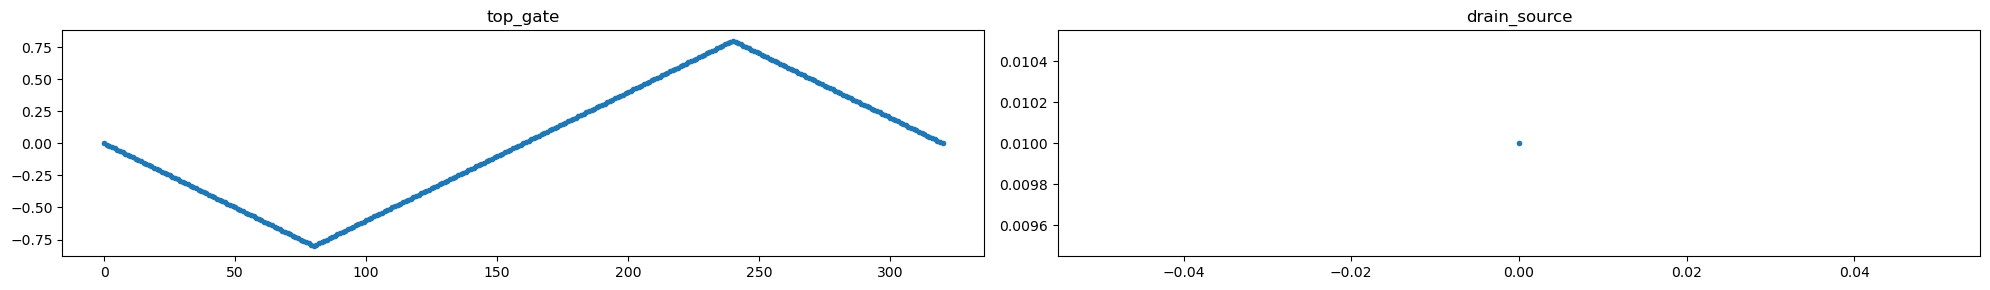

ramping top_gate to 0.0
ramping <Keithley2600Channel: keithley1_smub of Keithley2600: keithley1> from -0.000247955 to 0.0
ramping drain_source to 0.01
ramping <Keithley2600Channel: keithley1_smua of Keithley2600: keithley1> from 0.0101876 to 0.01
Delay for 1 s...
Starting sweeps
Starting experimental run with id: 3. 
Repeat: 0


0.3